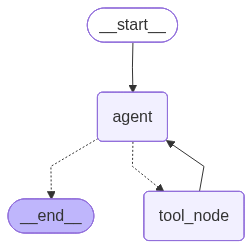

In [18]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END
from langchain_ollama import ChatOllama
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode
from ddgs import DDGS
from langchain_core.tools import tool

class ChildState(TypedDict):
    messages: Annotated[list, add_messages]

@tool
def search_tool(query:str) -> str:
    """
    Search any info regarding the query has been ask.

    Args:
        query: The search query

    Returns:
        Formatted search results with titles, descriptions, and URLs
    """

    results = DDGS().text(query)

    if not results:
        return "No results found"
    
    formatted_results = [f"Search results for search query: {query}\n"]

    for i, result in enumerate(results, 1):
        title = result.get('title', 'No title')
        href = result.get('href', '')
        body = result.get('body', 'No description available')

        text = f"{i}. **{title}**\n   {body}\n   {href}"

        formatted_results.append(text)

    return "\n\n".join(formatted_results)

tools = [search_tool]

llm = ChatOllama(model="qwen3:1.7b")

llm_with_tools = llm.bind_tools(tools=tools)

def agent(state: ChildState):

    system_prompt = f"""

    Use the search_tool to search the answer from web if you can't answer or less confidence to answer the user question.

    The question:
    {state['messages'][-1]}

    """

    messages = [
        SystemMessage(content=system_prompt)
    ] + state["messages"]

    return {
        "messages": [llm_with_tools.invoke(messages)],
    }

def tools_router(state: ChildState):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    

tool_node = ToolNode(tools=tools)

subgraph = StateGraph(ChildState)

subgraph.add_node("agent", agent)
subgraph.add_node("tool_node", tool_node)
subgraph.set_entry_point("agent")

subgraph.add_conditional_edges("agent", tools_router,["tool_node",END])
subgraph.add_edge("tool_node", "agent")

search_app = subgraph.compile()
search_app

In [19]:
search_app.invoke({"messages": [HumanMessage(content="Who found apple?")]})

{'messages': [HumanMessage(content='Who found apple?', additional_kwargs={}, response_metadata={}, id='ad0cc9c5-6ab2-4fa0-9358-c43a05ad5941'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T05:45:47.1977143Z', 'done': True, 'done_reason': 'stop', 'total_duration': 24434624100, 'load_duration': 309601000, 'prompt_eval_count': 237, 'prompt_eval_duration': 4015843200, 'eval_count': 388, 'eval_duration': 18551515300, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cad14-6c49-78e0-823a-0eb7dd1faecf-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'who found apple'}, 'id': 'c8bf5af3-b9a8-4cc9-9693-6a50871216f3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 388, 'total_tokens': 625}),
  ToolMessage(content="Search results for search query: who found apple\n\n\n1. **Apple Inc. - Wikipedia**\n   1976–1980: Founding and incor

Case 1: Shared Schema (Direct Embedding)

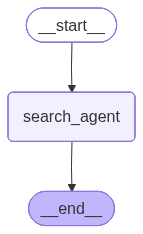

In [20]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_core.messages import HumanMessage

# Define parent graph with the same schema
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]

# Create parent graph
parent_graph = StateGraph(ParentState)

# Add the subgraph as a node
parent_graph.add_node("search_agent", search_app)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()
parent_app

In [21]:
result = parent_app.invoke({"messages": [HumanMessage(content="Who found apple?")]})
result

{'messages': [HumanMessage(content='Who found apple?', additional_kwargs={}, response_metadata={}, id='24af957a-0f2c-4cf2-9112-2d4b998b16f2'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T05:48:55.3853403Z', 'done': True, 'done_reason': 'stop', 'total_duration': 18994394500, 'load_duration': 260396800, 'prompt_eval_count': 241, 'prompt_eval_duration': 4219021400, 'eval_count': 274, 'eval_duration': 14389669000, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cad17-60a6-7ce0-9af9-3bb6d4ab97de-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'Who found apple?'}, 'id': 'c56502f2-60cb-4ac9-a222-f6a17bf24486', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 241, 'output_tokens': 274, 'total_tokens': 515}),
  ToolMessage(content='Search results for search query: Who found apple?\n\n\n1. **Apple Inc. - Wikipedia**\n   14 hours ago - Apple Inc. i

Case 2: Different Schema (Invoke with Transformation)

In [22]:
class QueryState(TypedDict):
    query: str
    response: str

# Function to invoke subgraph
def search_agent(state: QueryState):
    print(f"--- Calling Subgraph with query: {state['query']} ---")
    
    # 1. Prepare input for the child (which uses ChildState/messages)
    subgraph_input = {"messages": [HumanMessage(content=state["query"])]}
    
    # 2. Invoke the child
    subgraph_result = search_app.invoke(subgraph_input)
    
    # 3. Extract the LAST message carefully
    messages = subgraph_result.get("messages", [])
    if not messages:
        return {"response": "Error: Subgraph returned no messages."}
        
    last_msg = messages[-1]
    
    # 4. Debug: Print to see what's actually happening inside the node
    print(f"--- Subgraph output type: {last_msg.content} ---")
    
    # Return the content to the parent's 'response' key
    return {"response": last_msg.content}

# Create parent graph
parent_graph = StateGraph(QueryState)

# Add transformation node that invokes subgraph
parent_graph.add_node("search_agent", search_agent)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()

In [23]:
# Run the parent graph
result = parent_app.invoke({"query": "Who is the president of US?", "response": ""})
print(result)

--- Calling Subgraph with query: Who is the president of US? ---
--- Subgraph output type: As of January 20, 2025, **Donald John Trump** is the 47th and 45th President of the United States. He was sworn in on January 20, 2025, following the election on November 5, 2024. 

The search results confirm his role as the current president, with links to his official White House page and Wikipedia entry. For the most up-to-date information, please verify the current date, as presidential terms are staggered (e.g., Joe Biden is currently serving as the 46th president, with his term ending in 2024). 

Let me know if you need further details! ---
{'query': 'Who is the president of US?', 'response': 'As of January 20, 2025, **Donald John Trump** is the 47th and 45th President of the United States. He was sworn in on January 20, 2025, following the election on November 5, 2024. \n\nThe search results confirm his role as the current president, with links to his official White House page and Wikipedi